<a href="https://colab.research.google.com/github/hyeonggyeong-kim/comprehensive-project/blob/khg/ml/feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

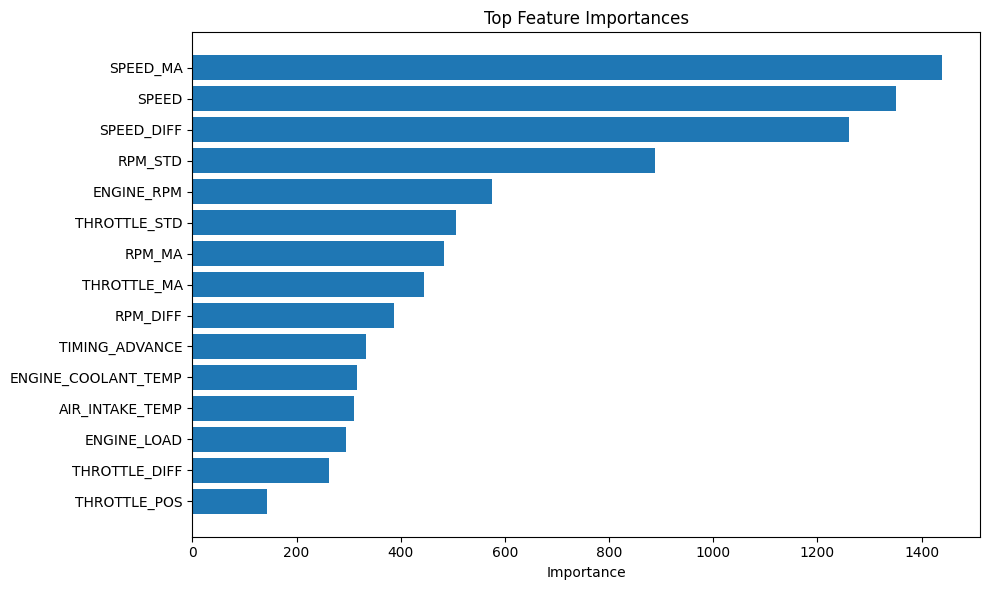

In [1]:
# =========================
# 라이브러리
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# =========================
# 데이터 로드
# =========================
file_path = "/content/sample_data/obd_merged_labeled.csv"
df = pd.read_csv(file_path, low_memory=False)
df.columns = df.columns.str.strip()

# =========================
# X, y 분리
# =========================
target_col = "DRIVING_STYLE"
leakage_cols = [
    "TIMESTAMP", target_col, "DATA_SOURCE",
    "HARSH_ACCEL", "HARSH_BRAKE", "HIGH_RPM", "HIGH_SPEED", "IDLING",
    "SPEED_STD", "HARSH_ACCEL_CUMSUM", "HARSH_BRAKE_CUMSUM",
    "HIGH_RPM_CUMSUM", "HIGH_SPEED_CUMSUM", "IDLING_CUMSUM"
]
drop_columns = [col for col in leakage_cols if col in df.columns]
X = df.drop(columns=drop_columns)
y = df[target_col]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =========================
# LightGBM 학습
# =========================
model = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
model.fit(X_train, y_train)

# =========================
# Feature Importance 시각화
# =========================
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()